<a href="https://colab.research.google.com/github/BrianaNzivu/Scancer/blob/main/Scancer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import cv2
from matplotlib.image import imread

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import glob
import PIL
import random
import zipfile
from google.colab import drive

# For consistent results
random.seed(100)

In [19]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Change directory to my dataset location
os.chdir('/content/drive/MyDrive/Dataset_BUSI_with_GT')

print(os.listdir())

['normal', 'malignant', 'benign']


Number of images in benign: 949
Number of images in malignant: 950
Number of images in normal: 950


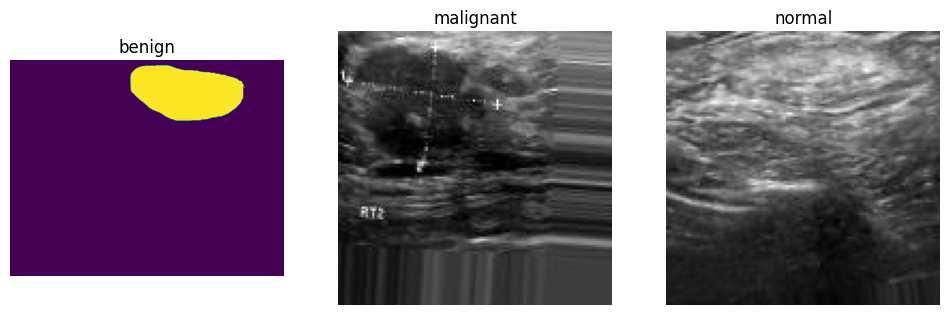

In [21]:
# Count images in each class
for class_name in ['benign', 'malignant', 'normal']:
    class_path = os.path.join('/content/drive/MyDrive/Dataset_BUSI_with_GT', class_name)
    num_images = len(os.listdir(class_path))
    print(f"Number of images in {class_name}: {num_images}")

# Visualize random images
plt.figure(figsize=(12, 6))
for i, class_name in enumerate(['benign', 'malignant', 'normal']):
    class_path = os.path.join('/content/drive/MyDrive/Dataset_BUSI_with_GT', class_name)
    random_image_path = os.path.join(class_path, random.choice(os.listdir(class_path)))
    img = imread(random_image_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.show()

In [22]:
# Data Augmetation to make sure for Malignant and Normal t have same no. as Benign
image_size = 128

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=45,  # Increased rotation
    width_shift_range=0.3,  # Increased shift
    height_shift_range=0.3,
    shear_range=0.3,  # Increased shear
    zoom_range=0.3,  # Increased zoom
    horizontal_flip=True,
    vertical_flip=True,  # Added vertical flip
    fill_mode='nearest'
)

# Count images in 'benign' class to determine target number
benign_path = os.path.join('/content/drive/MyDrive/Dataset_BUSI_with_GT', 'benign')
target_images = 950

# Augment 'malignant' and 'normal' classes
for class_name in ['malignant', 'normal', 'benign']:
    class_path = os.path.join('/content/drive/MyDrive/Dataset_BUSI_with_GT', class_name)
    num_augmentations = 0
    augmentations_needed = max(0, target_images - len(os.listdir(class_path)))

    for image_name in os.listdir(class_path):
        if num_augmentations >= augmentations_needed:
            break  # Stop augmenting if target reached

        image_path = os.path.join(class_path, image_name)
        img = cv2.imread(image_path)
        img = cv2.resize(img, (image_size, image_size))
        img = img.reshape((1,) + img.shape)

        i = 0
        for batch in datagen.flow(img, batch_size=1, save_to_dir=class_path, save_prefix='augmented_', save_format='jpeg'):
            i += 1
            num_augmentations += 1
            if i > 5 or num_augmentations >= augmentations_needed:
                break

In [23]:
#Preprocessing and Feature Extraction
images = []
labels = []

# Load and preprocess all images
for class_name in ['benign', 'malignant', 'normal']:
    class_path = os.path.join('/content/drive/MyDrive/Dataset_BUSI_with_GT', class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        img = cv2.imread(image_path)
        img = cv2.resize(img, (image_size, image_size))

        # Contrast Enhancement (using CLAHE)
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray_img = clahe.apply(gray_img) # Apply CLAHE to grayscale image

        # Noise Reduction (using Gaussian Blur)
        gray_img = cv2.GaussianBlur(gray_img, (5, 5), 0)

        # Edge Detection (using Canny)
        gray_img = cv2.Canny(gray_img, 100, 200)

        # Normalize pixel values
        img = img / 255.0
        images.append(img)
        labels.append(class_name)

# Convert labels to numerical values
label_mapping = {'benign': 0, 'malignant': 1, 'normal': 2}
labels = [label_mapping[label] for label in labels]

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

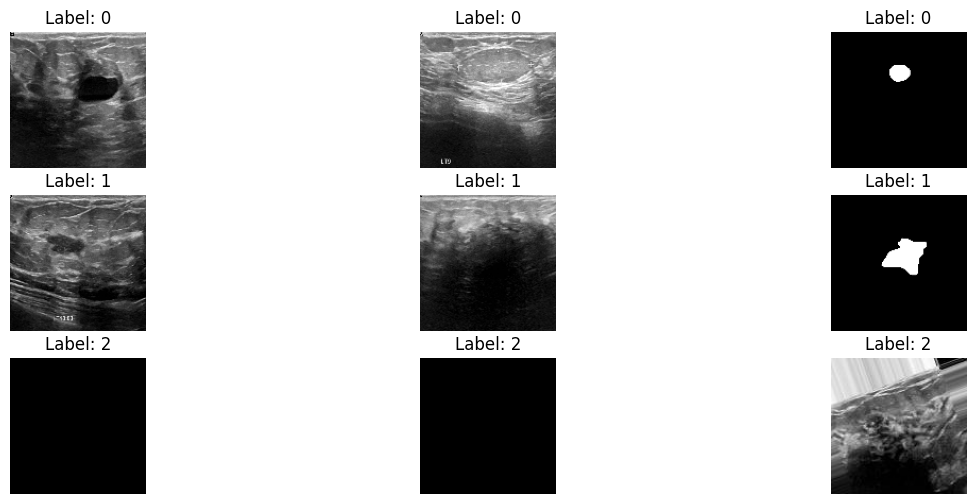

In [24]:
# Display a few preprocessed sample images
label_0_indices = np.where(labels == 0)[0]
label_1_indices = np.where(labels == 1)[0]
label_2_indices = np.where(labels == 2)[0]

# Display a few sample images from each label
plt.figure(figsize=(15, 6))
for i, label_indices in enumerate([label_0_indices, label_1_indices, label_2_indices]):
    for j in range(3):
        random_index = np.random.choice(label_indices)
        plt.subplot(3, 3, i * 3 + j + 1)
        plt.imshow(images[random_index], cmap='gray')
        plt.title(f"Label: {labels[random_index]}")
        plt.axis('off')
plt.show()

In [25]:
# Splitting preprcessed data to train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [43]:

# CNN Model Architecture

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_size, image_size, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [44]:
# Train the model (replace X_train, y_train with your actual training data)
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
72/72 [==============================] - 105s 1s/step - loss: 0.8730 - accuracy: 0.5596 - val_loss: 0.7282 - val_accuracy: 0.6333
Epoch 2/10
72/72 [==============================] - 102s 1s/step - loss: 0.7105 - accuracy: 0.6561 - val_loss: 0.6930 - val_accuracy: 0.6491
Epoch 3/10
72/72 [==============================] - 102s 1s/step - loss: 0.6403 - accuracy: 0.7061 - val_loss: 0.6808 - val_accuracy: 0.6737
Epoch 4/10
72/72 [==============================] - 97s 1s/step - loss: 0.5784 - accuracy: 0.7360 - val_loss: 0.6378 - val_accuracy: 0.7140
Epoch 5/10
72/72 [==============================] - 97s 1s/step - loss: 0.4898 - accuracy: 0.7956 - val_loss: 0.6821 - val_accuracy: 0.7175
Epoch 6/10
72/72 [==============================] - 90s 1s/step - loss: 0.4132 - accuracy: 0.8386 - val_loss: 0.6997 - val_accuracy: 0.7737
Epoch 7/10
72/72 [==============================] - 86s 1s/step - loss: 0.3398 - accuracy: 0.8649 - val_loss: 0.7320 - val_accuracy: 0.7684
Epoch 8/10
72/72 

In [45]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy}")

# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

Test Accuracy: 0.7649123072624207
18/18 [==============================] - 10s 494ms/step
Confusion Matrix:
[[143  48   7]
 [ 33 136  15]
 [  8  23 157]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       198
           1       0.66      0.74      0.70       184
           2       0.88      0.84      0.86       188

    accuracy                           0.76       570
   macro avg       0.77      0.77      0.77       570
weighted avg       0.77      0.76      0.77       570



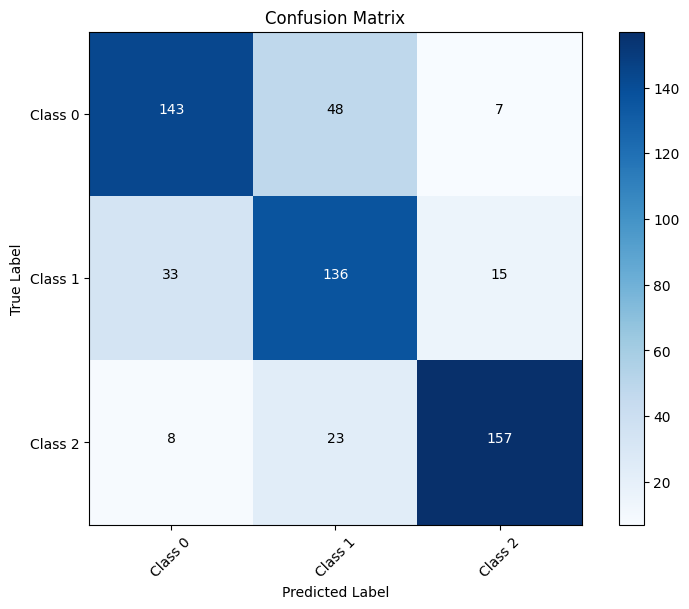

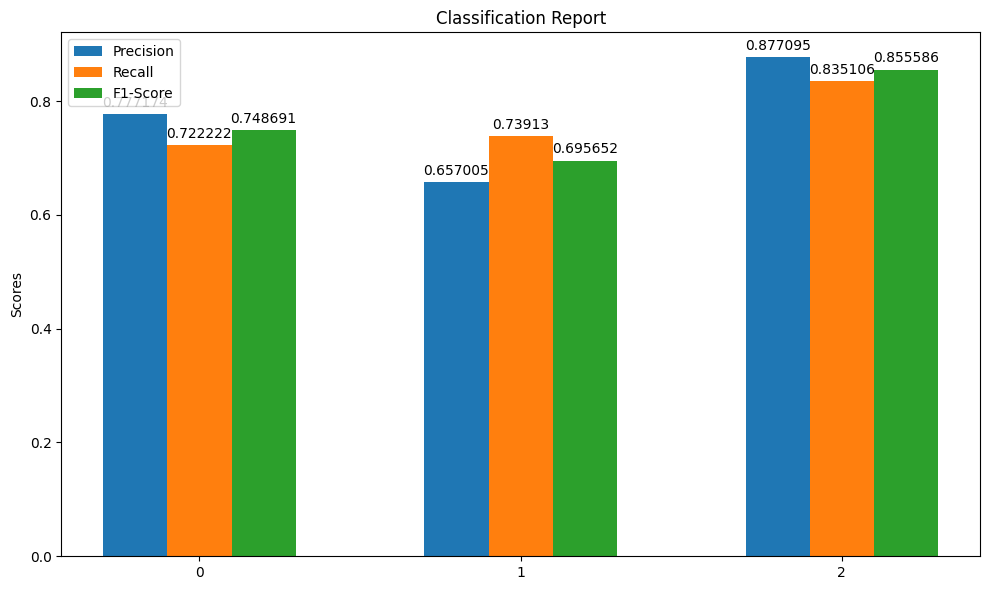

In [48]:
# Confusion Matrix Visualization
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have 3 classes: 'Class 0', 'Class 1', 'Class 2'
class_labels = ['Class 0', 'Class 1', 'Class 2'] # Define class_labels here

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report Visualization (Bar Chart)
from sklearn.metrics import classification_report

# Classification Report Visualization (Bar Chart)
report = classification_report(y_test, y_pred_classes, output_dict=True)

# Get the actual class labels from the report
class_labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'

metrics = ['precision', 'recall', 'f1-score']
data = {
    'Class': class_labels,
    'Precision': [report[label]['precision'] for label in class_labels],
    'Recall': [report[label]['recall'] for label in class_labels],
    'F1-Score': [report[label]['f1-score'] for label in class_labels]
}


x = np.arange(len(class_labels))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, data['Precision'], width, label='Precision')
rects2 = ax.bar(x, data['Recall'], width, label='Recall')
rects3 = ax.bar(x + width, data['F1-Score'], width, label='F1-Score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Classification Report')
ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
ax.bar_label(rects3, padding=3)

fig.tight_layout()
plt.show()

In [51]:
from google.colab import files
# Upload Image
uploaded = files.upload()

for fn in uploaded.keys():
  # Assuming the uploaded image is named 'image.jpg'
  image_path = fn
  img = cv2.imread(image_path)
  img = cv2.resize(img, (image_size, image_size))  # Resize to match your model input
  img = img / 255.0  # Normalize pixel values
  img = np.expand_dims(img, axis=0)  # Add batch dimension

  # Make prediction
  prediction = model.predict(img)
  predicted_class = np.argmax(prediction)

  class_labels = ['benign', 'malignant', 'normal']
  predicted_label = class_labels[predicted_class]

  print(f"Predicted Class: {predicted_label}")

Saving benign (4).png to benign (4).png
1/1 [==============================] - 0s 38ms/step
Predicted Class: benign
